Number of structures: 383


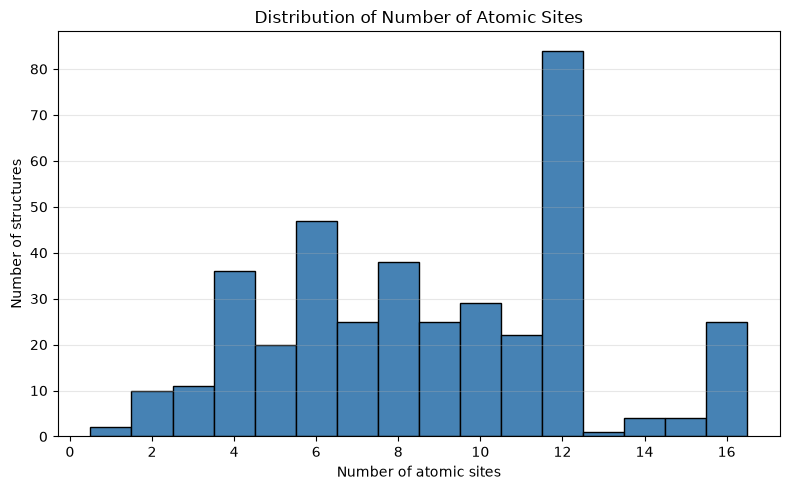

Analysing symmetry:   0%|          | 0/383 [00:00<?, ?it/s]

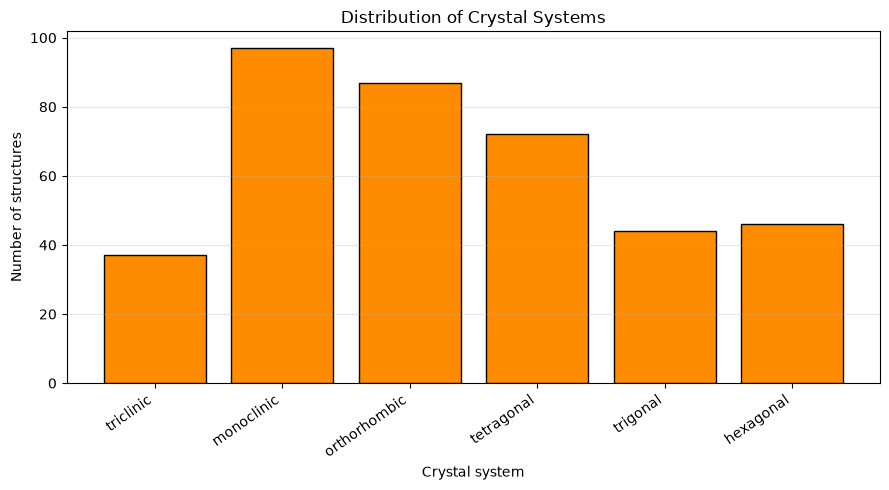

/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatviz/bar.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data[Key.crystal_system] = [spg_to_crystal_sys(x) for x in df_data.index]


Calculating coordination numbers:   0%|          | 0/383 [00:00<?, ?it/s]

/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatgen/core/local_env.py:4045: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatgen/core/local_env.py:4047: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatgen/core/local_env.py:3959: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


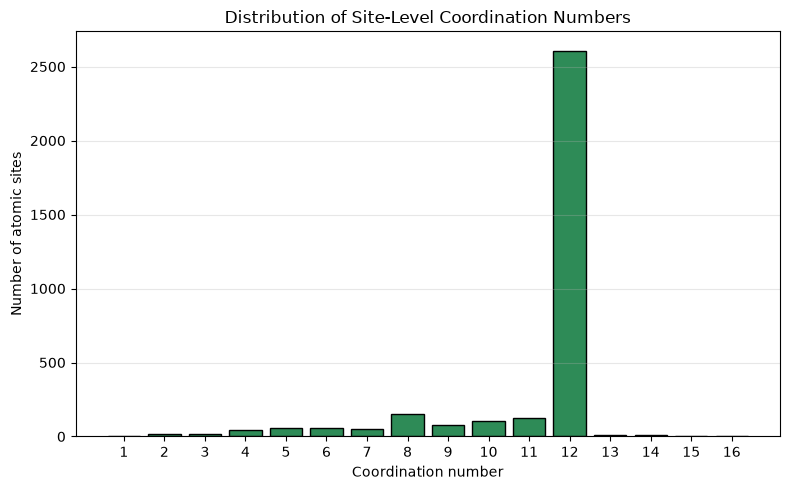

In [10]:
import json
from pathlib import Path
from collections import Counter
import numpy as np, matplotlib.pyplot as plt, pymatviz as pmv
from tqdm.auto import tqdm
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

clean_data = json.load(open("complete_database.json"))
structures = {sid: Structure.from_dict(s) for sid, s in clean_data["structure"].items()}
print("Number of structures:", len(structures))

# Plot 1: number of sites
site_counts = [s.num_sites for s in structures.values()]
bins = np.arange(min(site_counts) - 0.5, max(site_counts) + 1.5, 1)
plt.figure(figsize=(8, 5))
plt.hist(site_counts, bins=bins, color="steelblue", edgecolor="black")
plt.xlabel("Number of atomic sites"); plt.ylabel("Number of structures")
plt.title("Distribution of Number of Atomic Sites"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "distribution_n_sites.png", dpi=300); plt.show(); plt.close()

# Symmetry analysis
crystal_systems, space_group_numbers = [], []
for s in tqdm(structures.values(), desc="Analysing symmetry"):
    analyzer = SpacegroupAnalyzer(s, symprec=0.1, angle_tolerance=5)
    crystal_systems.append(analyzer.get_crystal_system())
    space_group_numbers.append(analyzer.get_space_group_number())

# Plot 2: crystal systems
order = ["triclinic", "monoclinic", "orthorhombic", "tetragonal", "trigonal", "hexagonal", "cubic"]
distribution = Counter(crystal_systems)
systems = [sys for sys in order if distribution[sys] > 0]
plt.figure(figsize=(9, 5))
plt.bar(systems, [distribution[sys] for sys in systems], color="darkorange", edgecolor="black")
plt.xlabel("Crystal system"); plt.ylabel("Number of structures")
plt.title("Distribution of Crystal Systems"); plt.xticks(rotation=35, ha="right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "distribution_crystal_systems.png", dpi=300); plt.show(); plt.close()

# Plot 3: space groups
fig = pmv.spacegroup_bar(space_group_numbers, xticks=12)
fig.update_layout(title="Distribution of Space-Group Types", width=1100, height=650, margin=dict(t=130, b=140))
fig.update_xaxes(title_standoff=25, automargin=True)
fig.show()

# Plot 4: coordination numbers
crystal_nn = CrystalNN()
coordination_numbers = []
for s in tqdm(structures.values(), desc="Calculating coordination numbers"):
    for i in range(len(s)):
        try:
            coordination_numbers.append(int(round(crystal_nn.get_cn(s, i))))
        except Exception:
            pass

distribution = Counter(coordination_numbers)
cn_values = sorted(distribution)
plt.figure(figsize=(8, 5))
plt.bar(cn_values, [distribution[v] for v in cn_values], color="seagreen", edgecolor="black")
plt.xlabel("Coordination number"); plt.ylabel("Number of atomic sites")
plt.title("Distribution of Site-Level Coordination Numbers"); plt.xticks(cn_values); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "distribution_coordination_numbers.png", dpi=300); plt.show(); plt.close()

In [ ]:
#Featurization: question1
#There were various frature that was relevent for finding bulk modulus:
#1 In composite feature we need to know the fraction of our materials, atomic size , electronegativity, and other elemental properties that we get from magpie.
#2 In structural feature we need to know density, volume , symmetry and packing fraction. Basicaaly global crystal structure.
#3 ChemEnv custom feature include local environment of material whic is also very releveant because while finding bulk properties we need to tae care of any local disstortion or nearby structures that influence things.

In [ ]:
#question2:
#Since our dataset already have the information about Cu.Pt and Cu-Pt fraction so we may not need those in composite feature. Aslo properties such as Atomic mass and so which directly does not decide bulk modulus are irrelevnt.
#K_reuss and K_voigt are not need as feature are it can be obtained form k_vrh which is average of them.

In [5]:
import json
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from matminer.featurizers.base import BaseFeaturizer, MultipleFeaturizer
from matminer.featurizers.composition import ElementFraction, ElementProperty, Stoichiometry, ValenceOrbital
from matminer.featurizers.structure import DensityFeatures, GlobalSymmetryFeatures
from matminer.featurizers.site import ChemEnvSiteFingerprint

with open("clean_database.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.index.name = "structure_id"
df["structure"] = df["structure"].apply(Structure.from_dict)
df["composition"] = df["structure"].apply(lambda s: s.composition)
print("Number of structures:", len(df))

# Composition features
comp_featurizer = MultipleFeaturizer([Stoichiometry(), ElementFraction(), ElementProperty.from_preset("magpie"), ValenceOrbital()])
comp_featurizer.set_n_jobs(1)
df = comp_featurizer.featurize_dataframe(df, col_id="composition", ignore_errors=True)

# Basic structural features
struct_featurizer = MultipleFeaturizer([DensityFeatures(), GlobalSymmetryFeatures()])
struct_featurizer.set_n_jobs(1)
df = struct_featurizer.featurize_dataframe(df, col_id="structure", ignore_errors=True)

# Custom ChemEnv statistical featurizer
class ChemEnvStats(BaseFeaturizer):
    def __init__(self):
        self.site_featurizer = ChemEnvSiteFingerprint.from_preset("simple")
        self.statistics = ("mean", "std", "min", "max")

    def featurize(self, structure):
        site_values = np.asarray([self.site_featurizer.featurize(structure, i) for i in range(len(structure))], dtype=float)
        values = []
        for fn in (np.mean, np.std, np.min, np.max):
            values.extend(fn(site_values, axis=0))
        return values

    def feature_labels(self):
        labels = self.site_featurizer.feature_labels()
        return [f"ChemEnv_{stat}_{label}" for stat in self.statistics for label in labels]

    def citations(self):
        return self.site_featurizer.citations()

    def implementors(self):
        return ["Custom ChemEnv statistical featurizer"]

chemenv_featurizer = ChemEnvStats()
chemenv_featurizer.set_n_jobs(1)
df = chemenv_featurizer.featurize_dataframe(df, col_id="structure", ignore_errors=True)

# Keep only numerical ML features (exclude k_reuss/k_voigt to avoid target leakage: k_vrh = (k_reuss + k_voigt) / 2)
non_feature_columns = ["structure", "composition", "chemsys", "n_sites", "k_reuss", "k_voigt", "k_vrh"]
X = df.drop(columns=non_feature_columns, errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how="all")

feature_dataset = pd.concat([df[["chemsys"]], X, df[["k_vrh"]]], axis=1)
feature_dataset.to_csv("features.csv", index=True, index_label="structure_id")

print("\nFeature generation completed")
print("Structures:", len(feature_dataset))
print("Input features:", X.shape[1])
print("Target: k_vrh")
print("Saved as: features.csv")

Number of structures: 384


MultipleFeaturizer:   0%|          | 0/384 [00:00<?, ?it/s]

MultipleFeaturizer:   0%|          | 0/384 [00:00<?, ?it/s]

ChemEnvStats:   0%|          | 0/384 [00:00<?, ?it/s]


Feature generation completed
Structures: 384
Input features: 515
Target: k_vrh
Saved as: features.csv


In [ ]:
#Question3
#The compositional feature which I used are Stoichiometry, ElementFraction, Magpie ElementProperty and ValenceOrbital.
# These features describe the Cu/Pt ratio, elemental-property statistics such as atomic size, electronegativity and atomic mass, and the fractions of electrons
#The structural feature were generated using DensityFeatures and GlobalSymmetryFeatures. 
# They include quantities related to density, volume per atom, packing efficiency, crystal system and space-group symmetry.
#I aslo used one custom feature that is ChemEnv which is ude to calculate mean, SD, min and max.
#The mean describes the dominant local coordination environment, while the other statistics capture variation and distortion between atomic sites.


#THis representation is choosen because to calculate bulk modulus we need crystal structure and chemical boding structure.
# Composite feature helps to distinguish between Pt,Cu, and Pt-Cu while structual feature help to get properties like density, packing fraction that are essential for bulk modulus.
# other features help to understand local structure , like neighbour arrangement of surrounding atoms and which structre resemble more to our structure.
# Since bulk modulus measn resistence to compression so that aslo depends on how loacl factor or structure influence it. 

In [ ]:
#Question4:
#Two feature slection method that were used were:
#1 Mutual-information method: Here each feature are evaluated independiently and the goal is to check which fetaure reduce the uncertainity from the target value.
# One of the disadvantage of this method is since it is evaluated independently we can sometimes miss the interaction bewteen two feature which might give better resuts.
# Moreover two correlated feature which give the same terget score might both get sellected.
#They are model indepindent.

#2 Model based slection: Here the model such as random forest is trained to evaluate the feature relevence from the reduction in prediction error produced by feature splits across its decision trees.
# Feature with highest importance value are retained. Since it is model dependentso correlated feature divide importance bewteen one another. 

#MODnet: This feature slection method is very similar to Mutual information with one addition that it adds on an explict redundancy penality for same feature selected.
#It normalize mutual information to identify feature related to the target while also penalizing feature that contain information already represented by previously selected features.

In [6]:
import json, numpy as np, pandas as pd
from functools import partial
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, SelectFromModel, VarianceThreshold, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

data = pd.read_csv("features.csv", index_col="structure_id")
y = data["k_vrh"]; X = data.drop(columns=["k_vrh", "chemsys"], errors="ignore")

selectors = {
    "random_mutual": (SelectKBest(partial(mutual_info_regression, random_state=42)), {"selector__k": [25, 50, 100, "all"]}),
    "random_model_based": (SelectFromModel(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1), threshold=-np.inf), {"selector__max_features": [25, 50, 100]}),
}
model_grid = {"model__n_estimators": [200, 500], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2]}
outer_cv, inner_cv = list(KFold(5, shuffle=True, random_state=42).split(X)), KFold(5, shuffle=True, random_state=42)

for name, (selector, selector_grid) in selectors.items():
    pipeline = Pipeline([("imputer", SimpleImputer(strategy="median", keep_empty_features=True)), ("variance", VarianceThreshold()), ("selector", selector), ("model", RandomForestRegressor(random_state=42, n_jobs=1))])
    metrics, importances, predictions = [], [], []
    for fold, (train, test) in enumerate(outer_cv, 1):
        search = GridSearchCV(pipeline, {**selector_grid, **model_grid}, cv=inner_cv, scoring="neg_mean_absolute_error", n_jobs=-1).fit(X.iloc[train], y.iloc[train])
        best, pred = search.best_estimator_, search.best_estimator_.predict(X.iloc[test])
        predictions.extend({"fold": fold,"structure_id": sid,"actual": actual,"predicted": predicted} for sid, actual, predicted in zip(X.index[test],y.iloc[test],pred))
        names = np.asarray(X.columns)[best["variance"].get_support()][best["selector"].get_support()]
        metrics.append({"fold": fold, "MAE": mean_absolute_error(y.iloc[test], pred), "RMSE": np.sqrt(mean_squared_error(y.iloc[test], pred)), "R2": r2_score(y.iloc[test], pred), "n_features": len(names), "best_parameters": json.dumps(search.best_params_)})
        importances.extend({"fold": fold, "feature": n, "importance": i} for n, i in zip(names, best["model"].feature_importances_))
    pd.DataFrame(metrics).to_csv(f"{name}_metrics.csv", index=False)
    pd.DataFrame(importances).to_csv(f"{name}_importances.csv", index=False)
    pd.DataFrame(predictions).to_csv(f"{name}_predictions.csv", index=False)
    print(name, "\n", pd.DataFrame(metrics)[["MAE", "RMSE", "R2"]].agg(["mean", "std"]))

random_mutual 
            MAE      RMSE        R2
mean  4.066542  9.781761  0.876580
std   0.935936  5.479040  0.108252
random_model_based 
            MAE       RMSE        R2
mean  4.224142  10.081607  0.870845
std   0.883415   5.302236  0.105087


In [7]:
import json, numpy as np, pandas as pd
from functools import partial
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, SelectFromModel, VarianceThreshold, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

data = pd.read_csv("features.csv", index_col="structure_id")
y = data["k_vrh"]; X = data.drop(columns=["k_vrh", "chemsys"], errors="ignore")

selectors = {
    "gradient_mutual": (SelectKBest(partial(mutual_info_regression, random_state=42)), {"selector__k": [25, 50, 100, "all"]}),
    "gradient_model_based": (SelectFromModel(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1), threshold=-np.inf), {"selector__max_features": [25, 50, 100]}),
}
model_grid = {"model__n_estimators": [100, 300], "model__learning_rate": [0.03, 0.1], "model__max_depth": [2, 3]}
outer_cv, inner_cv = list(KFold(5, shuffle=True, random_state=42).split(X)), KFold(5, shuffle=True, random_state=42)

for name, (selector, selector_grid) in selectors.items():
    pipeline = Pipeline([("imputer", SimpleImputer(strategy="median", keep_empty_features=True)), ("variance", VarianceThreshold()), ("selector", selector), ("model", GradientBoostingRegressor(random_state=42))])
    metrics, importances, predictions = [], [], []
    for fold, (train, test) in enumerate(outer_cv, 1):
        search = GridSearchCV(pipeline, {**selector_grid, **model_grid}, cv=inner_cv, scoring="neg_mean_absolute_error", n_jobs=-1).fit(X.iloc[train], y.iloc[train])
        best, pred = search.best_estimator_, search.best_estimator_.predict(X.iloc[test])
        predictions.extend({"fold": fold,"structure_id": sid,"actual": actual,"predicted": predicted} for sid, actual, predicted in zip(X.index[test],y.iloc[test],pred))
        names = np.asarray(X.columns)[best["variance"].get_support()][best["selector"].get_support()]
        metrics.append({"fold": fold, "MAE": mean_absolute_error(y.iloc[test], pred), "RMSE": np.sqrt(mean_squared_error(y.iloc[test], pred)), "R2": r2_score(y.iloc[test], pred), "n_features": len(names), "best_parameters": json.dumps(search.best_params_)})
        importances.extend({"fold": fold, "feature": n, "importance": i} for n, i in zip(names, best["model"].feature_importances_))
    pd.DataFrame(metrics).to_csv(f"{name}_metrics.csv", index=False)
    pd.DataFrame(importances).to_csv(f"{name}_importances_feature.csv", index=False)
    pd.DataFrame(predictions).to_csv(f"{name}_predictions.csv", index=False)
    print(name, "\n", pd.DataFrame(metrics)[["MAE", "RMSE", "R2"]].agg(["mean", "std"]))

gradient_mutual 
            MAE      RMSE        R2
mean  4.150780  9.622970  0.881023
std   1.046491  5.132313  0.095612
gradient_model_based 
            MAE      RMSE        R2
mean  3.846433  9.773092  0.874672
std   1.145476  5.718470  0.112750


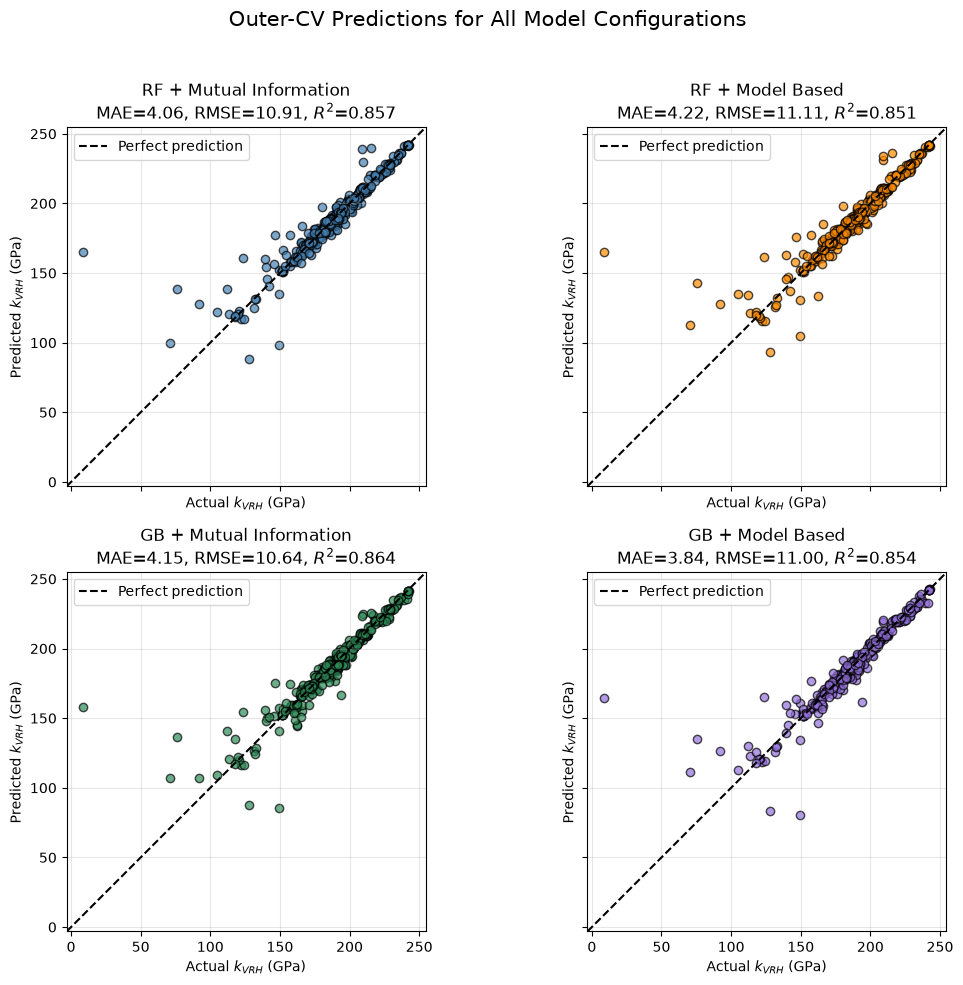

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

files = {"RF + Mutual Information": "random_mutual_predictions.csv", "RF + Model Based": "random_model_based_predictions.csv",
          "GB + Mutual Information": "gradient_mutual_predictions.csv", "GB + Model Based": "gradient_model_based_predictions.csv"}
data = {name: pd.read_csv(f) for name, f in files.items()}

all_values = np.concatenate([df[["actual", "predicted"]].to_numpy().ravel() for df in data.values()])
lower, upper = all_values.min(), all_values.max()
pad = 0.05 * (upper - lower); lower, upper = lower - pad, upper + pad

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

for ax, (name, df), color in zip(axes.flat, data.items(), colors):
    actual, predicted = df["actual"], df["predicted"]
    mae, rmse, r2 = mean_absolute_error(actual, predicted), np.sqrt(mean_squared_error(actual, predicted)), r2_score(actual, predicted)
    ax.scatter(actual, predicted, color=color, alpha=0.7, edgecolor="black")
    ax.plot([lower, upper], [lower, upper], "k--", label="Perfect prediction")
    ax.set_xlim(lower, upper); ax.set_ylim(lower, upper); ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.3)
    ax.set_title(f"{name}\nMAE={mae:.2f}, RMSE={rmse:.2f}, $R^2$={r2:.3f}")
    ax.set_xlabel("Actual $k_{VRH}$ (GPa)"); ax.set_ylabel("Predicted $k_{VRH}$ (GPa)"); ax.legend()

plt.suptitle("Outer-CV Predictions for All Model Configurations", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("all_models_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Question5: 
#If slection were performed on outer CV then there will be overfitting and data leakage, as model will also examine our target on the outer test data. SO to stop thiswe use inner CV as seperate container.
 

In [ ]:
#Question6:
#Random forest:
#trees are trained independintly and final prediction take avergare of many trees
#usually reduce prediction variance and less sensitive to tunning.
#use random feature subset

#Gradient boosting:
#trees are trained sequientally and final prediction adds on the contribution of previous tree.
#reduces prediction bias and are more sensitive to tuning and overfitting
#each tree corrects error from previous one.

#There in no strictly better model between two but we we comapre through MAE GB+ model based sight outperform others.

In [ ]:
#question7:

import pandas as pd

files = {"RF + Mutual Information": "random_mutual_importances.csv", "RF + Model Based": "random_model_based_importances.csv",
          "GB + Mutual Information": "gradient_mutual_importances_feature.csv", "GB + Model Based": "gradient_model_based_importances_feature.csv"}

output = []
for model, file in files.items():
    data = pd.read_csv(file)
    summary = data.groupby("feature").agg(importance_sum=("importance", "sum"), selected_folds=("fold", "nunique"))
    summary["mean_importance"] = summary["importance_sum"] / 5
    chem = summary[summary.index.str.startswith("ChemEnv_")]
    total_chem = chem["mean_importance"].sum()

    top_overall = summary.sort_values("mean_importance", ascending=False).head(5).reset_index()
    top_overall["category"] = "Top overall"
    top_chem = chem.sort_values("mean_importance", ascending=False).head(5).reset_index()
    top_chem["category"] = "Top ChemEnv"

    for df in (top_overall, top_chem):
        df["model"], df["total_ChemEnv_importance"] = model, total_chem
    output.extend([top_overall, top_chem])

important_features = pd.concat(output, ignore_index=True)[["model", "category", "feature", "mean_importance", "selected_folds", "total_ChemEnv_importance"]]
important_features.to_csv("important_features.csv", index=False)
display(important_features)
print("Saved as: important_features.csv")

,model,category,feature,mean_importance,selected_folds,total_ChemEnv_importance
0,RF + Mutual Information,Top overall,density,0.767351,5,0.035495
1,RF + Mutual Information,Top overall,packing fraction,0.075846,5,0.035495
2,RF + Mutual Information,Top overall,vpa,0.070842,5,0.035495
3,RF + Mutual Information,Top overall,ChemEnv_min_C:12,0.008161,3,0.035495
4,RF + Mutual Information,Top overall,ChemEnv_mean_AC:12,0.005706,3,0.035495
5,RF + Mutual Information,Top ChemEnv,ChemEnv_min_C:12,0.008161,3,0.035495
6,RF + Mutual Information,Top ChemEnv,ChemEnv_mean_AC:12,0.005706,3,0.035495
7,RF + Mutual Information,Top ChemEnv,ChemEnv_max_AC:12,0.004181,3,0.035495
8,RF + Mutual Information,Top ChemEnv,ChemEnv_mean_I:12,0.003948,3,0.035495
9,RF + Mutual Information,Top ChemEnv,ChemEnv_mean_C:12,0.003423,3,0.035495


Saved as: important_features.csv
